In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pyfield
import pyfield.transducers as transducers
from pyfield.psimulation import PyField


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# PyField Simulations for IdV

## 1. Model experimental validation

A linear array probe with 128 elements with 110 $\mu m$ pitch, an elevation focus of 8 mm, and a center frequency of 15 MHz was calibrated using the Acertara Acoustic Measurement System (AMS). This system combines hardware and software for characterizing acoustic energy from diagnostic and therapeutic ultrasound devices, and includes a water treatment unit for degassing and filtration. A calibrated hydrophone (Onda HGL-0085, SN: 2852) with an integral preamplifier (AG-2010, SN: 1403) was mounted on a 3D motorized positioning system. The hydrophone output was recorded using a Tektronix MDO3012B oscilloscope.

The probe was driven by a Verasonics research ultrasound system to generate a focused sequence. To characterize the lateral and elevational field distribution, ten XY scans were acquired at depths of 4.5, 5.5, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 10.5, and 11.5 mm. To capture the axial pressure distribution, a Z-scan was performed along the central axis (x, y = 0, 0) from 4.5 to 11.5 mm with a step size of 0.01 mm, from which the peak intensity integral (PII) was extracted. By combining interpolation of the XY scans with the axial profile, a high-resolution 3D pressure field was reconstructed and later compared with simulation results.


### 1.1. Import experimental data

In [232]:
folder = 'Data_exp/'
name_exp_data = 'calibration_data_FD1_FD15_FD2.npz'
path_exp_data = folder + name_exp_data
Exp_data = np.load(path_exp_data, allow_pickle=True)
data = Exp_data['processed_data'].item()
print(data.keys())

# empirical corrections due spatial offset between simulation and experiment
shift_z_mm = 0.50
shift_x_mm = 0.03
shift_y_mm = 0.00
real_x1, real_y1, real_z1, real_FD1 = data['x1']-shift_x_mm, data['y1']-shift_y_mm, data['z1'] - shift_z_mm, data['FD1']
real_x15, real_y15, real_z15, real_FD15 = data['x15']-shift_x_mm, data['y15']-shift_y_mm, data['z15'] - shift_z_mm, data['FD15']
real_x2, real_y2, real_z2, real_FD2 = data['x2']-shift_x_mm, data['y2']-shift_y_mm, data['z2'] - shift_z_mm, data['FD2']

dict_keys(['FD1', 'x1', 'y1', 'z1', 'FD15', 'x15', 'y15', 'z15', 'FD2', 'x2', 'y2', 'z2'])


### 1.2. Perform simulations

Preparation of data for simulation

LinearArrayTransducer initialized in 0.0070 seconds.


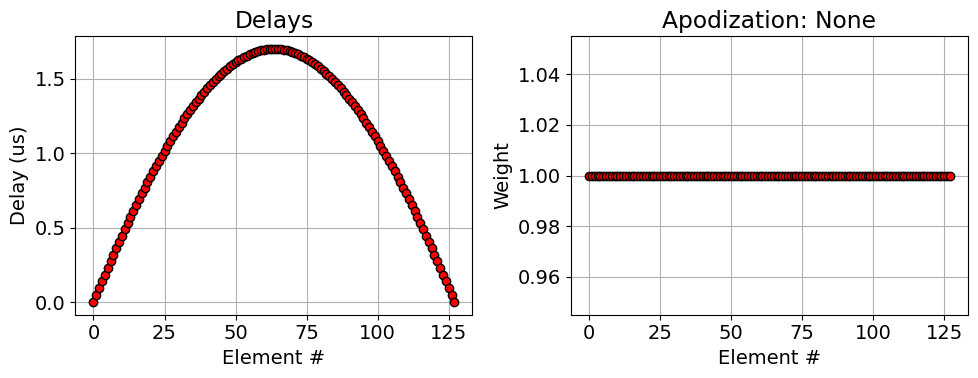

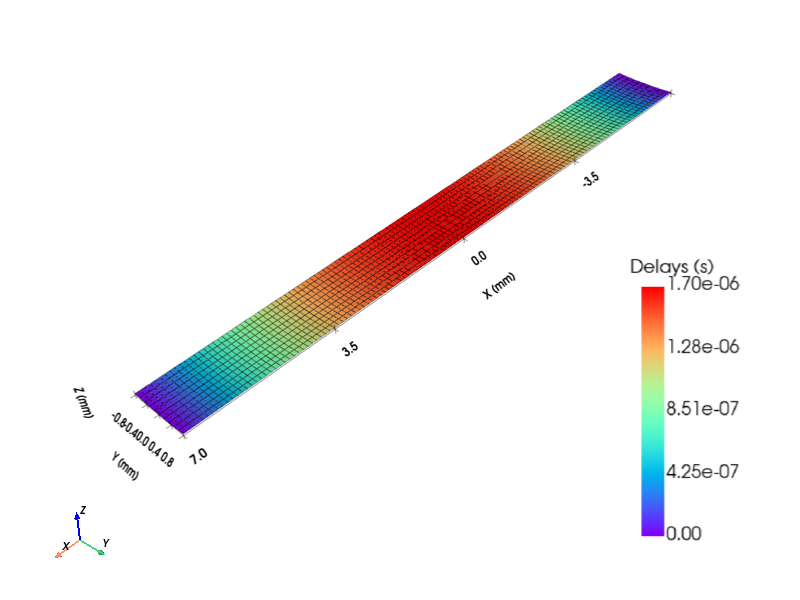

In [233]:
focus_mm = np.array([0, 0, 8])
method = 'sdi'

domino = transducers.Domino()
delays = domino.compute_delays(focus_mm=focus_mm)
domino.plot_delays_apodization()
domino.show(notebook=True, jupyter_backend='static', scalars = 'Delays')
 
field_points_FD1 = np.meshgrid(real_x1, real_y1, real_z1)
field_points_FD1 = np.array(field_points_FD1).T.reshape(-1, 3)

field_points_FD15 = np.meshgrid(real_x15, real_y15, real_z15)
field_points_FD15 = np.array(field_points_FD15).T.reshape(-1, 3)    

field_points_FD2 = np.meshgrid(real_x2, real_y2, real_z2)
field_points_FD2 = np.array(field_points_FD2).T.reshape(-1, 3)


Simulation with F/D = 1 :

In [ ]:
FoverD = 1
apodization = domino.compute_apodization( 
    focus_mm=focus_mm, FoverD=FoverD, apodization_type='rect')
# domino.plot_delays_apodization()

domino_field = PyField(domino)
pressure_FD1, _ = domino_field(field_points_FD1, method = method)
simu_x1, simu_y1, simu_z1 = real_x1, real_y1, real_z1

Simulation with F/D = 1.5 :

In [ ]:
FoverD = 1.5
apodization = domino.compute_apodization( 
    focus_mm=focus_mm, FoverD=FoverD, apodization_type='rect')
# domino.plot_delays_apodization()

domino_field = PyField(domino)
pressure_FD15, _ = domino_field(field_points_FD15, method = method)
simu_x15, simu_y15, simu_z15 = real_x15, real_y15, real_z15

Simulation with F/D = 2 :

In [ ]:
FoverD = 2
apodization = domino.compute_apodization( 
    focus_mm=focus_mm, FoverD=FoverD, apodization_type='rect')
# domino.plot_delays_apodization()

domino_field = PyField(domino)
pressure_FD2, _ = domino_field(field_points_FD2, method = method)
simu_x2, simu_y2, simu_z2 = real_x2, real_y2, real_z2

Normalize the simulation and rescale them with the maximum value measured during calibration.

In [237]:
# Normalize
pressure_FD1 /= np.max(np.abs(pressure_FD1))
pressure_FD15 /= np.max(np.abs(pressure_FD15))
pressure_FD2 /= np.max(np.abs(pressure_FD2))

# Convert to PII
simu_FD1 = np.max(real_FD1)*pressure_FD1**2
simu_FD15 = np.max(real_FD15)*pressure_FD15**2
simu_FD2 = np.max(real_FD2)*pressure_FD2**2

### 1.3. 3D Visualization of pressure fields

In [ ]:
import pyfield.utilities.plotting_pyvista as pv_plotting
import pyvista as pv

def set_custom_style(plotter):
    cube_actor =plotter.show_bounds(
            grid = 'back', color = 'black', font_size = 12,
            location = 'outer',
            n_xlabels =3 , n_ylabels=5, n_zlabels=13-5,
            xtitle = "X (mm)", ytitle = "Y (mm)", ztitle = "Z (mm)",
            )
    # turn on outer gridlines and inner gridlines if you want them
    cube_actor.DrawXGridlinesOn()
    cube_actor.DrawYGridlinesOn()
    cube_actor.DrawZGridlinesOn()

    # set gridline colors to white (RGB in 0..1)
    cube_actor.GetXAxesGridlinesProperty().SetColor(1.0, 1.0, 1.0)
    cube_actor.GetYAxesGridlinesProperty().SetColor(1.0, 1.0, 1.0)
    cube_actor.GetZAxesGridlinesProperty().SetColor(1.0, 1.0, 1.0)

    # (optional) tweak gridline width
    cube_actor.GetXAxesGridlinesProperty().SetLineWidth(2.0)
    cube_actor.GetYAxesGridlinesProperty().SetLineWidth(2.0)
    cube_actor.GetZAxesGridlinesProperty().SetLineWidth(2.0)

    plotter.camera_position = [(-11.790359626834173, -11.502976928133164, 4.9699041703133755),
    (0.0, 0.0, 8.0),
    (0.12778591723122387, 0.12809234170411485, -0.9834953540073949)]  # Set the camera position
    plotter.camera.up = (0, 0, -1)

def plot_volume(x,y,z, PII, *, notebook = True, jupyter_backend = 'static', image_name = None, off_screen = False, save_screenshot = False):
    # if image_name is None:
    window_size = (420,720)

    if image_name is not None:
        save_screenshot = True
        off_screen = True
    else:
        save_screenshot = False

    pv.global_theme.anti_aliasing = 'ssaa' 
    pressure_mesh = pv_plotting.create_vol_mesh(x, y, z, PII, scalars='Pressure')
    box = pressure_mesh.bounding_box()

    plotter = pv.Plotter(title='FD1 Real Data', notebook = notebook, window_size = window_size, off_screen= off_screen)
    _ = plotter.add_mesh(box,opacity=0.2, color='#b0b0b0')

    plotter = pv_plotting.add_pressure_vol(pressure_mesh, plotter=plotter, title = 'PII₀ (μJ/cm²)')

    set_custom_style(plotter)

    if save_screenshot:
        plotter.screenshot(image_name)

    plotter.show(jupyter_backend=jupyter_backend)



Plotting F/D = 2 : real and simulated


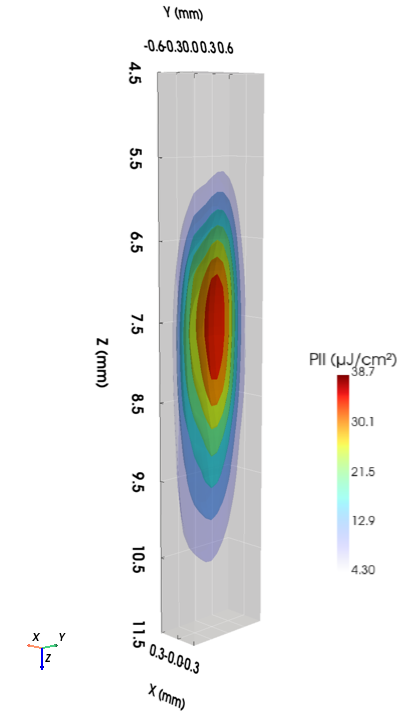

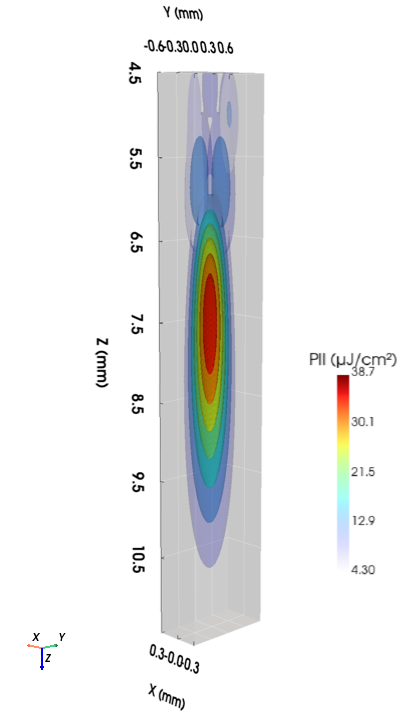

In [239]:
# print('Plotting F/D = 1 : real and simulated')
# plot_volume(real_x1, real_y1, real_z1, real_FD1, image_name=folder+'FD1_real.png') #, image_name = 'FD1_real.png')
# plot_volume(simu_x1, simu_y1, simu_z1, simu_FD1, image_name=folder+f'FD1_simu{method}.png') #, image_name = 'FD1_real.png')

# print('Plotting F/D = 1.5 : real and simulated')
# plot_volume(real_x15, real_y15, real_z15, real_FD15, image_name=folder+'FD15_real.png') #, image_name = 'FD1_real.png')
# plot_volume(simu_x15, simu_y15, simu_z15, simu_FD15, image_name=folder+f'FD15_simu{method}.png') #, image_name = 'FD1_real.png')

print('Plotting F/D = 2 : real and simulated')
plot_volume(real_x2, real_y2, real_z2, real_FD2, image_name=folder+'FD2_real.png') #, image_name = 'FD1_real.png')
plot_volume(simu_x2, simu_y2, simu_z2, simu_FD2, image_name=folder+f'FD2_simu{method}.png') #, image_name = 'FD1_real.png')

### 1.4. 2D Visualization of pressure field

In [247]:
import matplotlib.gridspec as gridspec

fontsize = 11
plt.rcParams.update({'font.size': fontsize})

def plot_comparison_slices(x,y,z, field1, field2, *, figsize = (10,8), xslice = 0, yslice = 0, zslice = 8, interpolation = 'bilinear', cmap = 'jet'):
    
    slice_idx = np.argmin(np.abs(x - xslice))
    slice_idy = np.argmin(np.abs(y - yslice))
    slice_idz = np.argmin(np.abs(z - zslice))

    print(f"slice_idx: {slice_idx}, slice_idy: {slice_idy}, slice_idz: {slice_idz}")
    print(f"xslice (mm): {x[slice_idx]:.2f}, yslice (mm): {y[slice_idy]:.2f}, zslice (mm): {z[slice_idz]:.2f}")

    vmin = min(field1.min(), field2.min())
    vmax = max(field1.max(), field2.max())

    # Make a grid row 2 and 5 columns
    # first column plane xz field1
    # second column plane xz field2
    # first row third column plane yx field1
    # second row third column plane yx field2
    # fourth column plane zy field1
    # fifth column plane zy field2

    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(2, 6, figure=fig, width_ratios=[0.5, 0.5, 1, 0.8, 0.8, 0.05])

    # a) XZ slices planes
    ax_xz_1 = fig.add_subplot(gs[:, 0])

    im = ax_xz_1.imshow(field1[:, slice_idy, :].T, extent=[x.min(), x.max(), z.max(), z.min()], cmap=cmap, interpolation=interpolation, vmin=vmin, vmax=vmax)
    ax_xz_1.set_xlabel('x (mm)')
    ax_xz_1.set_ylabel('z (mm)')
    ax_xz_1.set_xticks([x.min(), 0, x.max()])
    ax_xz_1.set_xticklabels([f"{x.min():.1f}", "0", f"{x.max():.1f}"])
    ax_xz_1.set_title('a)')
    
    ax_xz_2 = fig.add_subplot(gs[:, 1])
    ax_xz_2.imshow(field2[:, slice_idy, :].T, extent=[x.min(), x.max(), z.max(), z.min()], cmap=cmap, interpolation=interpolation, vmin=vmin, vmax=vmax)
    ax_xz_2.set_xlabel('x (mm)')
    ax_xz_2.set_ylabel('z (mm)')
    ax_xz_2.set_xticks([x.min(), 0, x.max()])
    ax_xz_2.set_xticklabels([f"{x.min():.1f}", "0", f"{x.max():.1f}"])
    ax_xz_2.set_title('b)')

    # b) YX slices planes
    ax_yx_1 = fig.add_subplot(gs[0, 2])
    im = ax_yx_1.imshow(field1[:, :, slice_idz].T, extent=[x.min(), x.max(), y.max(), y.min()], cmap=cmap, interpolation=interpolation, vmin=vmin, vmax=vmax)
    ax_yx_1.set_xlabel('x (mm)')
    ax_yx_1.set_ylabel('y (mm)')
    ax_yx_1.set_title('c)')

    ax_yx_2 = fig.add_subplot(gs[1, 2])
    ax_yx_2.imshow(field2[:, :, slice_idz].T, extent=[x.min(), x.max(), y.max(), y.min()], cmap=cmap, interpolation=interpolation, vmin=vmin, vmax=vmax)
    ax_yx_2.set_xlabel('x (mm)')
    ax_yx_2.set_ylabel('y (mm)')
    ax_yx_2.set_title('d)')

    # c) ZY slices planes
    ax_zy_1 = fig.add_subplot(gs[:, 3])
    im = ax_zy_1.imshow(field1[slice_idx, :, :].T, extent=[y.min(), y.max(), z.max(), z.min()], cmap=cmap, interpolation=interpolation, vmin=vmin, vmax=vmax)
    ax_zy_1.set_xlabel('y (mm)')
    ax_zy_1.set_ylabel('z (mm)')
    ax_zy_1.set_title('e)')
    
    ax_zy_2 = fig.add_subplot(gs[:, 4])
    ax_zy_2.imshow(field2[slice_idx, :, :].T, extent=[y.min(), y.max(), z.max(), z.min()], cmap=cmap, interpolation=interpolation, vmin=vmin, vmax=vmax)
    ax_zy_2.set_xlabel('y (mm)')
    ax_zy_2.set_ylabel('z (mm)')
    ax_zy_2.set_title('f)')

    # Add colorbar to the right of the last column
    # Make it span both rows
    cax = fig.add_subplot(gs[:, 5])
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label('PII₀ (μJ/cm²)')
    plt.tight_layout()
    return fig                     

def plot_comparison_contours(x, y, z, field1, field2, *, figsize=(10, 8), xslice=0, yslice=0, zslice=8, cmap='jet', levels=15):
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gridspec
    import numpy as np

    slice_idx = np.argmin(np.abs(x - xslice))
    slice_idy = np.argmin(np.abs(y - yslice))
    slice_idz = np.argmin(np.abs(z - zslice))

    print(f"slice_idx: {slice_idx}, slice_idy: {slice_idy}, slice_idz: {slice_idz}")
    print(f"xslice (mm): {x[slice_idx]:.2f}, yslice (mm): {y[slice_idy]:.2f}, zslice (mm): {z[slice_idz]:.2f}")

    vmin = min(field1.min(), field2.min())
    vmax = max(field1.max(), field2.max())

    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(2, 6, figure=fig, width_ratios=[0.5, 0.5, 1, 0.8, 0.8, 0.05])

    # a) XZ slices planes
    ax_xz_1 = fig.add_subplot(gs[:, 0])
    X, Z = np.meshgrid(x, z)
    cf1 = ax_xz_1.contourf(x, z, field1[:, slice_idy, :].T, levels=levels, cmap=cmap, vmin=vmin, vmax=vmax)
    ax_xz_1.set_xlabel('x (mm)')
    ax_xz_1.set_ylabel('z (mm)')
    ax_xz_1.set_xticks([x.min(), 0, x.max()])
    ax_xz_1.set_xticklabels([f"{x.min():.2f}", "0", f"{x.max():.2f}"])
    ax_xz_1.invert_yaxis()
    ax_xz_1.set_title('a)')

    ax_xz_2 = fig.add_subplot(gs[:, 1])
    cf2 = ax_xz_2.contourf(x, z, field2[:, slice_idy, :].T, levels=levels, cmap=cmap, vmin=vmin, vmax=vmax)
    ax_xz_2.set_xlabel('x (mm)')
    ax_xz_2.set_ylabel('z (mm)')
    ax_xz_2.set_xticks([x.min(), 0, x.max()])
    ax_xz_2.set_xticklabels([f"{x.min():.2f}", "0", f"{x.max():.2f}"])
    ax_xz_2.invert_yaxis()
    ax_xz_2.set_title('b)')

    # b) YX slices planes
    ax_yx_1 = fig.add_subplot(gs[0, 2])
    cf3 = ax_yx_1.contourf(x, y, field1[:, :, slice_idz].T, levels=levels, cmap=cmap, vmin=vmin, vmax=vmax)
    ax_yx_1.set_xlabel('x (mm)')
    ax_yx_1.set_ylabel('y (mm)')
    ax_yx_1.invert_yaxis()
    ax_yx_1.set_title('c)')

    ax_yx_2 = fig.add_subplot(gs[1, 2])
    cf4 = ax_yx_2.contourf(x, y, field2[:, :, slice_idz].T, levels=levels, cmap=cmap, vmin=vmin, vmax=vmax)
    ax_yx_2.set_xlabel('x (mm)')
    ax_yx_2.set_ylabel('y (mm)')
    ax_yx_2.invert_yaxis()
    ax_yx_2.set_title('d)')

    # c) ZY slices planes
    ax_zy_1 = fig.add_subplot(gs[:, 3])
    cf5 = ax_zy_1.contourf(y, z, field1[slice_idx, :, :].T, levels=levels, cmap=cmap, vmin=vmin, vmax=vmax)
    ax_zy_1.set_xlabel('y (mm)')
    ax_zy_1.set_ylabel('z (mm)')
    ax_zy_1.invert_yaxis()
    ax_zy_1.set_title('e)')

    ax_zy_2 = fig.add_subplot(gs[:, 4])
    cf6 = ax_zy_2.contourf(y, z, field2[slice_idx, :, :].T, levels=levels, cmap=cmap, vmin=vmin, vmax=vmax)
    ax_zy_2.set_xlabel('y (mm)')
    ax_zy_2.set_ylabel('z (mm)')
    ax_zy_2.invert_yaxis()
    ax_zy_2.set_title('f)')

    # Add colorbar to the right of the last column (use the last contourf for colorbar)
    cax = fig.add_subplot(gs[:, 5])
    cbar = fig.colorbar(cf6, cax=cax)
    cbar.set_label('PII₀ (μJ/cm²)')
    plt.tight_layout()
    return fig



slice_idx: 38, slice_idy: 64, slice_idz: 99
xslice (mm): 0.00, yslice (mm): -0.00, zslice (mm): 7.98
slice_idx: 38, slice_idy: 64, slice_idz: 119
xslice (mm): 0.00, yslice (mm): -0.00, zslice (mm): 7.99
slice_idx: 38, slice_idy: 64, slice_idz: 99
xslice (mm): 0.00, yslice (mm): -0.00, zslice (mm): 7.98


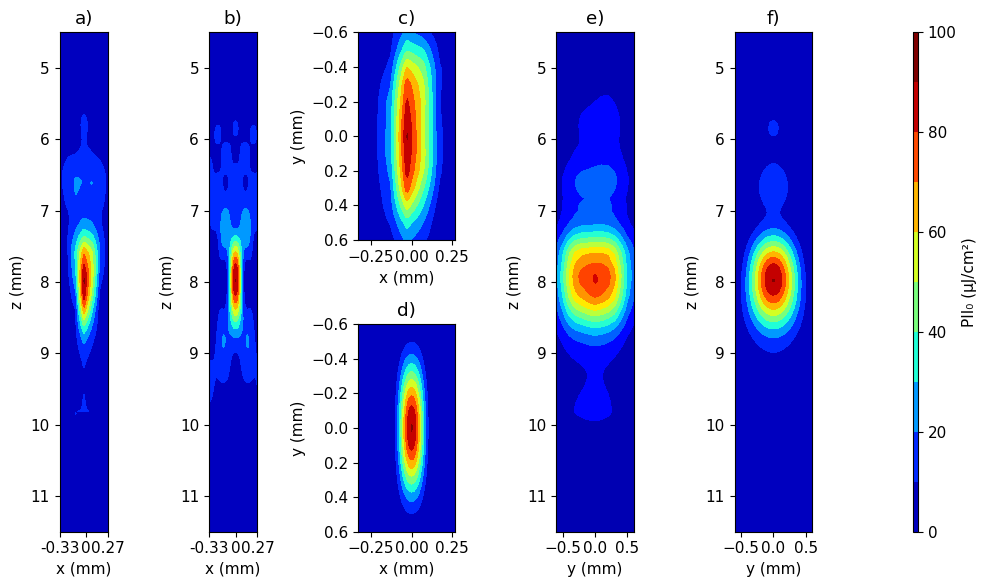

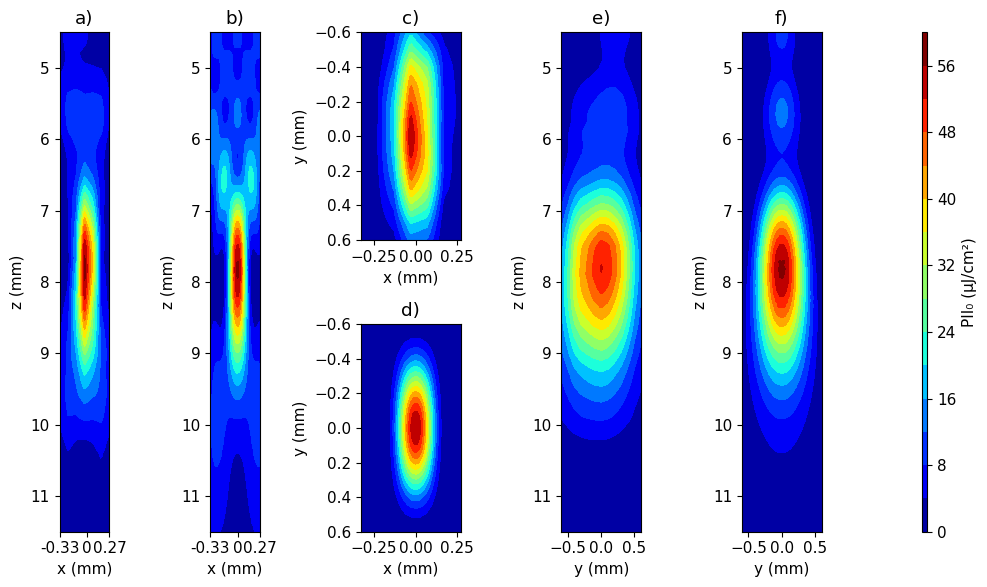

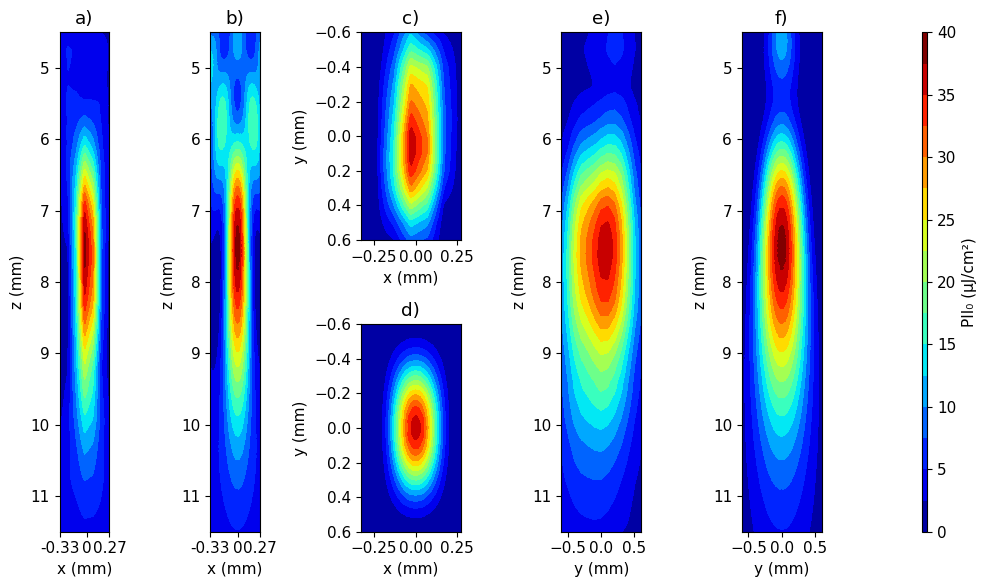

In [248]:
fig_cFD1 = plot_comparison_contours(real_x1, real_y1, real_z1, real_FD1, simu_FD1, figsize = (10,6), levels = 10)
fig_cFD15 = plot_comparison_contours(real_x15, real_y15, real_z15, real_FD15, simu_FD15, figsize = (10,6))
fig_cFD2 = plot_comparison_contours(real_x2, real_y2, real_z2, real_FD2, simu_FD2, figsize = (10,6))

In [242]:
# fig_FD1 = plot_comparison_slices(real_x1, real_y1, real_z1, real_FD1, simu_FD1, figsize = (10,6))
# fig_FD15 = plot_comparison_slices(real_x15, real_y15, real_z15, real_FD15, simu_FD15, figsize = (10,6))
# fig_FD2 = plot_comparison_slices(real_x2, real_y2, real_z2, real_FD2, simu_FD2, figsize = (10,6))

In [243]:
# fig_FD1.savefig(folder+f'Comparison_FD1{method}.png', dpi=300)
# fig_FD15.savefig(folder+f'Comparison_FD15{method}.png', dpi=300)
# fig_FD2.savefig(folder+f'Comparison_FD2{method}.png', dpi=300)
# fig_cFD1.savefig(folder+f'Comparison_contour_FD1{method}.png', dpi=300)
# fig_cFD15.savefig(folder+f'Comparison_contour_FD15{method}.png', dpi=300)
# fig_cFD2.savefig(folder+f'Comparison_contour_FD2{method}.png', dpi=300)

### 1.5 1D visualization of pressure

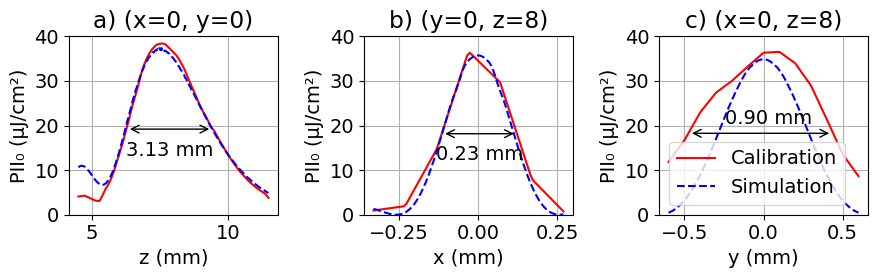

In [254]:
# Increase figure font size
fontsize = 14
plt.rcParams.update({'font.size': fontsize})
# Take x =0, y = 0, and z = 8.
indx = simu_FD2.shape[0]//2
indy = simu_FD2.shape[1]//2
indz = simu_FD2.shape[2]//2
z_linesimu = simu_FD2[indx, indy, :]
x_linesimu = simu_FD2[:, indy, indz]
y_linesimu = simu_FD2[indx, :, indz]
z_line = real_FD2[indx, indy, :]
x_line = real_FD2[:, indy, indz]
y_line = real_FD2[indx, :, indz]

# Compute half maximum width
def half_max_width(x, y):
    half_max = np.max(y) / 2
    indices = np.where(y >= half_max)[0]
    if len(indices) < 2:
        return None  # Not enough points above half max
    left_idx = indices[0]
    right_idx = indices[-1]
    x_left = x[left_idx]
    x_right = x[right_idx]
    width = x[right_idx] - x[left_idx]
    return x_left, x_right, half_max, width

fig, ax = plt.subplots(1,3, figsize=(9,3))
ax = ax.flatten()

# Compute half maximum widths
xlz, xrz, half_max_z, width_z = half_max_width(real_z2, z_line)
ax[0].plot(real_z2, z_line, 'r-', label='Calibration')
ax[0].plot(simu_z2, z_linesimu, 'b--', label='Simulation')

ax[0].annotate(text='', xy=(xlz, half_max_z), xytext=(xrz, half_max_z), arrowprops=dict(arrowstyle='<->'))
ax[0].annotate(text=f'{width_z:0.2f} mm', xy=((xlz+xrz)/2, half_max_z), xytext=((xlz+xrz)/2, half_max_z-6), fontsize=fontsize, ha='center')

ax[0].set_xlabel('z (mm)')
ax[0].set_ylabel('PII₀ (μJ/cm²)')
ax[0].set_title('a) (x=0, y=0)')
# ax[0].legend()
ax[0].grid()
ax[0].set_ylim(0,40)

xlx, xrx, half_max_x, width_x = half_max_width(real_x2, x_line)
ax[1].plot(real_x2, x_line, 'r-', label='Calibration')
ax[1].plot(simu_x2, x_linesimu, 'b--', label='Simulation')
ax[1].annotate(text='', xy=(xlx, half_max_x), xytext=(xrx, half_max_x), arrowprops=dict(arrowstyle='<->'))
ax[1].annotate(text=f'{width_x:0.2f} mm', xy=((xlx+xrx)/2, half_max_x), xytext=((xlx+xrx)/2, half_max_x-6), fontsize=fontsize, ha='center')

ax[1].set_xlabel('x (mm)')
ax[1].set_ylabel('PII₀ (μJ/cm²)')
ax[1].set_title('b) (y=0, z=8)')
# ax[1].legend()
ax[1].grid()
ax[1].set_ylim(0,40)

yly, yry, half_max_y, width_y = half_max_width(real_y2, y_line)
ax[2].plot(real_y2, y_line, 'r-', label='Calibration')
ax[2].plot(simu_y2, y_linesimu, 'b--', label='Simulation')
ax[2].annotate(text='', xy=(yly, half_max_y), xytext=(yry, half_max_y), arrowprops=dict(arrowstyle='<->'))
ax[2].annotate(text=f'{width_y:0.2f} mm', xy=((yly+yry)/2, half_max_y), xytext=((yly+yry)/2+0.05, half_max_y+2), fontsize=fontsize, ha='center')
ax[2].set_xlabel('y (mm)')
ax[2].set_ylabel('PII₀ (μJ/cm²)')
ax[2].set_title('c) (x=0, z=8)')
ax[2].legend()
ax[2].grid()
ax[2].set_ylim(0,40)
fig.tight_layout()


## 2. Simulations of stimulation

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pyfield
import pyfield.transducers as transducers
import pyvista as pv    
from PyField import PyField



%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 2.1. Preparation of stimulation grid

Create the focalization sites

In [75]:
x_focus = np.linspace(0, 10, 11)
z_focus = np.linspace(0, 16, 11)
y_focus = 0

print('scanned x positions: ', x_focus)
print('scanned z positions: ', z_focus)

FoverD = 2
apodization_type = 'rect'
method = 'auto'

domino = transducers.Domino()

freq = domino.fc

# field properties (Water)
water = {
    "c" : 1540, # m/s
    "alpha0" : 2.2e-3, # dB/(MHz^y cm)
    "freq_power" : 2
}
brain = {
    "c" : 1546, # m/s
    "alpha0" : 0.5912, # dB/(MHz^y cm)
    "freq_power" : 1.2
}

brain2 = {
    "c" : 1546, # m/s
    "alpha0" : 0.5912, # dB/(MHz^y cm)
    "freq_power" : 1.1
}

print('ratio brain/water alpha_abs: ', brain['alpha0']*(freq*1e-6)**brain['freq_power']/(water['alpha0']*(freq*1e-6)**water['freq_power']))



scanned x positions:  [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
scanned z positions:  [ 0.   1.6  3.2  4.8  6.4  8.   9.6 11.2 12.8 14.4 16. ]
LinearArrayTransducer initialized in 0.0131 seconds.
ratio brain/water alpha_abs:  35.62736754638909


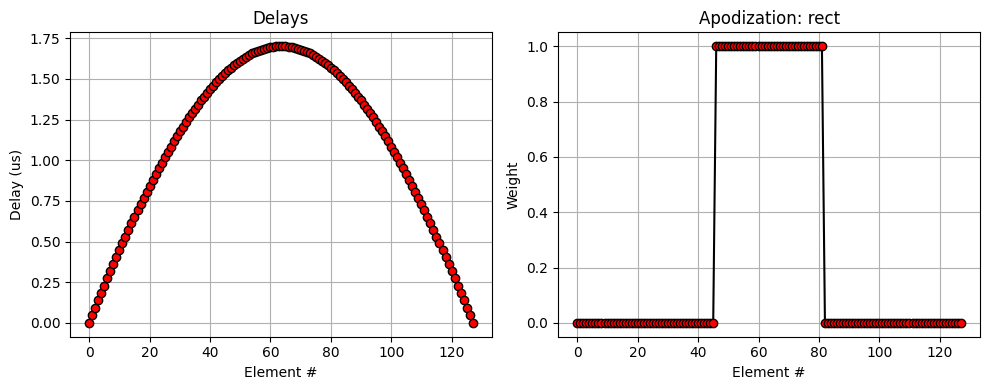

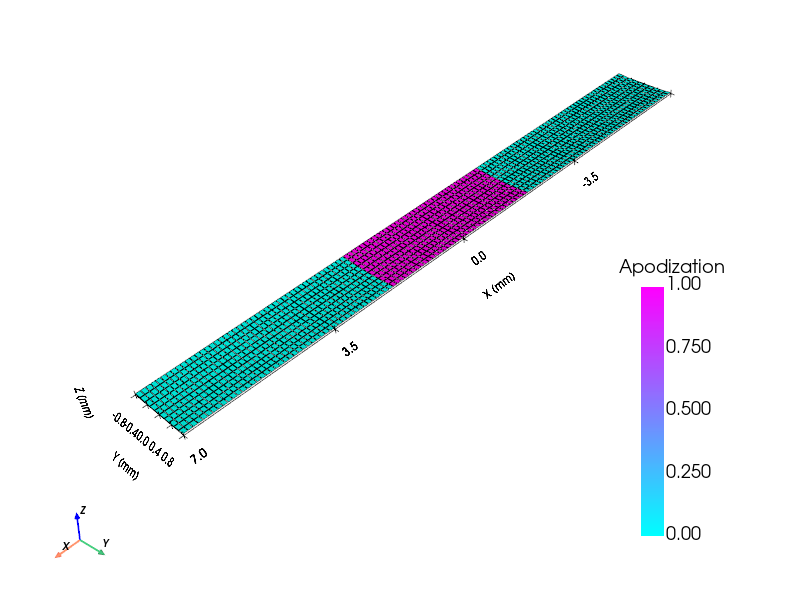

In [78]:

# Increase figure font size
fontsize = 10
plt.rcParams.update({'font.size': fontsize})
focus_mm = np.array([0, 0, 8])

delays = domino.compute_delays(focus_mm=focus_mm)
apodization = domino.compute_apodization( 
    focus_mm=focus_mm, FoverD=FoverD, apodization_type=apodization_type)
domino.plot_delays_apodization()
domino.show(notebook=True, jupyter_backend='static', scalars = 'Apodization')

field_info_mm = {
"x_extent" : [-2+focus_mm[0], 2+focus_mm[0]],
"y_extent" : [-2+focus_mm[1], 2+focus_mm[1]],
"z_extent" : [-5+focus_mm[2], 2+focus_mm[2]],
"dx" : 0.05,
"dy" : 0.05,
"dz" : 0.05,
}


In [ ]:
domino_field = PyField(domino)
pressure, coords = domino_field(field_info_mm, method = method)
x, y, z = coords["x"], coords["y"], coords["z"]

Taking slice (0.0,0.0,7.65) => x_ind, y_ind, z_ind = 41/81, 41/81, 94/141


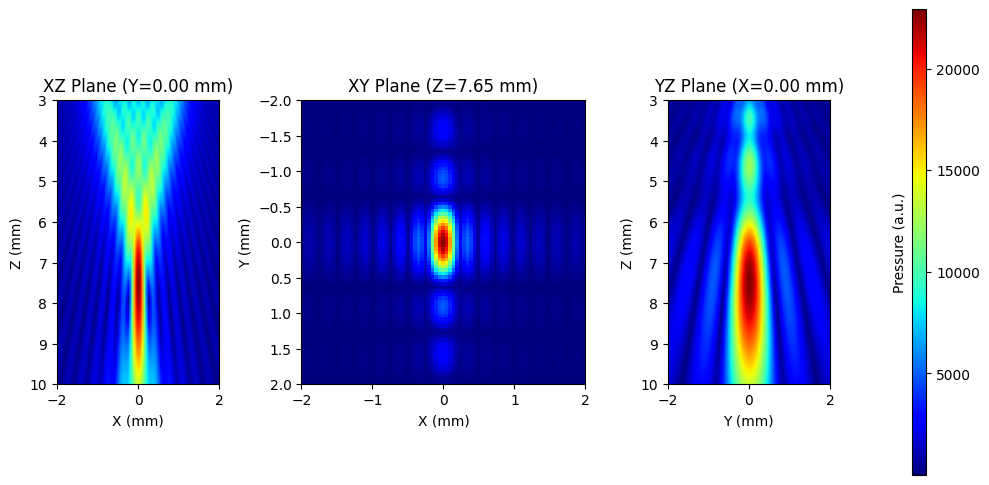

In [ ]:
pyfield.plot_field_planes(x, y, z, pressure, centered_to_max=True)

Show the transducer and the pressure field on the same space

In [ ]:
from pyfield.functions import create_vol_mesh, add_pressure_vol, add_transducer_mesh, recompute_bounds
transducer_mesh = domino.get_mesh()
pressure_mesh = create_vol_mesh(x, y, z, pressure, scalars='Pressure')

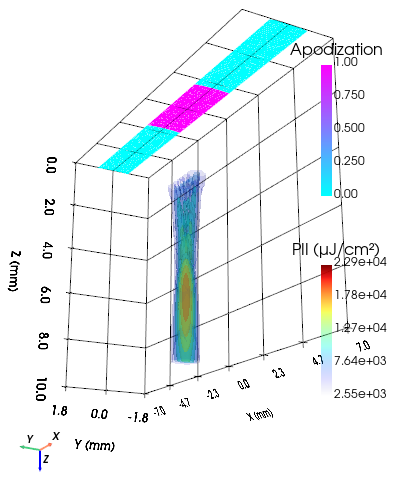

In [83]:
pv.global_theme.anti_aliasing = 'msaa'

plotter = pv.Plotter(title='FD2 Simulated Data', notebook = True, window_size = (400,500))
plotter = add_transducer_mesh(transducer_mesh, plotter=plotter, ambient = 1, show_edges = False)
plotter = add_pressure_vol(pressure_mesh, plotter=plotter, title = 'PII₀ (μJ/cm²)', ambient = 0, lighting = True)
bounds = recompute_bounds(plotter)
# draw grid look but force the axes ranges to the union of all meshes
plotter.show_grid(
    axes_ranges=bounds,               # lock the grid to the full scene bounds
    font_size=10,
    xtitle="X (mm)",
    ytitle="Y (mm)",
    ztitle="Z (mm)",
    show_zlabels=True,
    location='outer',                  # keep labels outside
    n_ylabels=3,
    n_xlabels=7,
    n_zlabels=6,
)

# draw nicely formatted numeric ticks/labels on every face so you can confirm the ranges
# plotter.show_bounds(
#     bounds=bounds,
#     grid='all',                       # draw grid lines on every face
#     location='all',                   # draw label triads on every face
#     color='black',
#     font_size=12,
#     n_xlabels=10,
#     n_ylabels=3,
#     n_zlabels=8,
#     xtitle="X (mm)",
#     ytitle="Y (mm)",
#     ztitle="Z (mm)",
# )
plotter.camera_position = [(29.042933099761175, 15.635482060903525, 16.55180514757528),
 (0.21708189787623677, -0.4672430595162802, 5.78452321695515),
 (0.32900874348323017, 0.0418492604368831, -0.9433991128427416)]
plotter.camera.up = (0, 0, -1)  # Set the camera up direction
plotter.show(jupyter_backend='static')


### 2.2. Loop over stimulation grid

In [18]:
def plot_plane(x, z, plane, *, xlabel='x (mm)', ylabel='z (mm)', title='', figsize=(6,5), cmap='jet', interpolation=None):
    plt.figure(figsize=figsize)
    plt.imshow(plane.T, extent=[x.min(), x.max(), z.max(), z.min()], aspect='equal', cmap=cmap, interpolation=interpolation)
    plt.colorbar(label='Pressure (a.u.)')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)    
    plt.title(title)
    plt.show()
    return

In [ ]:
plot_planes = True
max_pressure = np.zeros((len(x_focus), len(z_focus)))
focal_pressure = np.zeros((len(x_focus), len(z_focus)))
max_locations = np.zeros((len(x_focus), len(z_focus), 2))
planes = []
focal_dimension = np.zeros((len(x_focus), len(z_focus), 2)) # dx, dz

threshold = 0.7

Delta_z = 3
counter = 0

for z_i, zf in enumerate(z_focus):
    for x_i, xf in enumerate(x_focus):
        
        if zf == 0:
            max_locations[x_i, z_i, :] = [xf, zf]
            continue

        focus_mm = np.array([xf, y_focus, zf])
        print(f'Computing focus at: {focus_mm} mm')
        # delays = domino.compute_delays(focus_mm=focus_mm)
        # apodization = domino.compute_apodization( 
        #     focus_mm=focus_mm, FoverD=FoverD, apodization_type=apodization_type)
        # domino_field = PyField(domino) 
        
        # shift a lil
        x_shift_simu = 0
        z_shift_simu = 0
        if xf >= 7 and zf > 5 :
            z_shift_simu += -2

        if xf > 8.5 :
            x_shift_simu += -1

        field_info_mm = {
        "x_extent" : [-2+focus_mm[0]+x_shift_simu, 2+focus_mm[0]+x_shift_simu],
        "y_extent" : [-0.05+focus_mm[1], 0.05+focus_mm[1]],
        "z_extent" : [-Delta_z+focus_mm[2]+z_shift_simu, Delta_z+focus_mm[2]+z_shift_simu],
        "dx" : 0.05,
        "dy" : 0.05,
        "dz" : 0.055,
        }

        domino_field.compute_delays(focus_mm=focus_mm)
        domino_field.compute_apodization( 
            focus_mm=focus_mm, FoverD=FoverD, apodization_type=apodization_type)


        pressure, coords = domino_field(field_info_mm, method = method)
        x, y, z = coords["x"], coords["y"], coords["z"]

        print(f"pressure field shape:{pressure.shape}")
        # ind_y = len(y)//2
        plane_xz = np.mean(pressure, axis=1)

        # Take the max pressure value
        pr_max = np.max(pressure)
        max_pressure[x_i, z_i] = pr_max
        x_max, y_max, z_max =  np.unravel_index(np.argmax(pressure), pressure.shape)

        dx = x[1] - x[0]
        dz = z[1] - z[0]
        # Extract focal width and height at 50% of max pressure
        vertical_max_line = plane_xz[x_max, :]/pr_max >= threshold
        horizontal_max_line = plane_xz[:, z_max]/pr_max >= threshold

        # Compute the focal dimensions in mm
        focal_dimension[x_i, z_i, 0] = np.sum(horizontal_max_line)*dx  # dx
        focal_dimension[x_i, z_i, 1] = np.sum(vertical_max_line)*dz  # dz
        print(f'Focal dimensions (at {threshold*100:.0f}% max): dx = {focal_dimension[x_i, z_i, 0]:.2f} mm, dz = {focal_dimension[x_i, z_i, 1]:.2f} mm')

        # Take the pressure value at point of focalization
        x_if, y_if, z_if = np.argmin(np.abs(x - xf)), np.argmin(np.abs(y - y_focus)), np.argmin(np.abs(z - zf))
        focal_pressure[x_i, z_i] = pressure[x_if, y_if, z_if]

        max_locations[x_i, z_i,0] = x[x_max]
        max_locations[x_i, z_i,1] = z[z_max]
        print(f'Max pressure at: {max_locations[x_i, z_i]} m \n')
        
        # pyfield.plot_field_planes(pressure,x,y,z, ratios=ratios)
        if plot_planes:
            plot_plane(x, z, plane_xz) # title='x-z plane at y=0 mm')
        
        # Save the plane
        planes.append(plane_xz)

### 2.3. Analyse stimulation grid

In [20]:
focal_shift = np.zeros((len(x_focus), len(z_focus)))
focal_location = np.zeros((len(x_focus), len(z_focus), 2))

counter = 0
for z_i, zf in enumerate(z_focus):
    if zf > 5:
        counter += 1
    for x_i, xf in enumerate(x_focus):
        focal_location[x_i, z_i,0] = xf
        focal_location[x_i, z_i,1] = zf
        focal_shift[x_i, z_i] = np.sqrt((xf-max_locations[x_i, z_i,0])**2 + (zf-max_locations[x_i, z_i,1])**2)
        

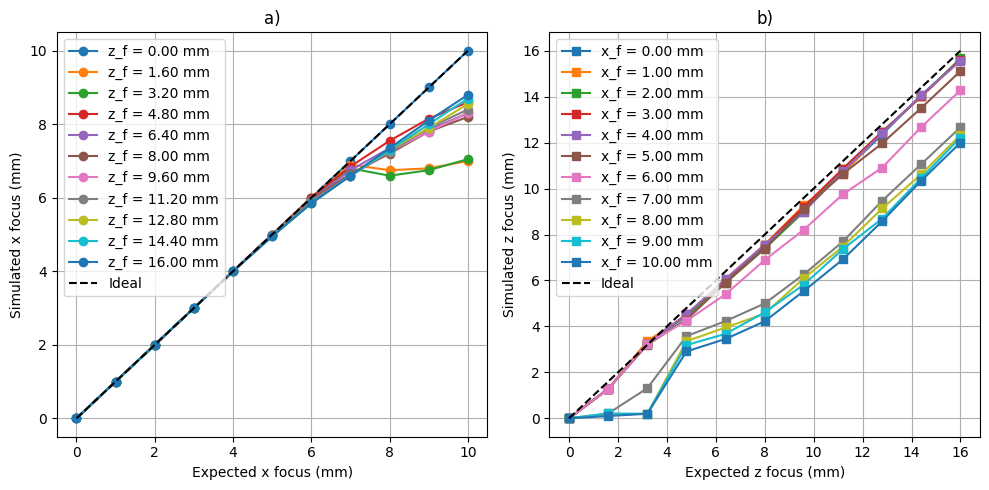

In [21]:
fig, ax = plt.subplots(1,2,figsize=(10,5))

for i in range(len(z_focus)):
    ax[0].plot(np.squeeze(focal_location[:, i, 0]), np.squeeze(max_locations[:, i, 0]), 'o-', label = f'z_f = {z_focus[i]:.2f} mm')

ax[0].plot([0, 10], [0, 10], 'k--', label = 'Ideal')
ax[0].set_xlabel('Expected x focus (mm)')
ax[0].set_ylabel('Simulated x focus (mm)')
ax[0].set_title('a)')
ax[0].legend()
ax[0].grid('minor')

for i in range(len(x_focus)):
    ax[1].plot(np.squeeze(focal_location[i, :, 1]), np.squeeze(max_locations[i, :, 1]), 's-', label = f'x_f = {x_focus[i]:.2f} mm')
ax[1].plot([0, 16], [0, 16], 'k--', label = 'Ideal')
ax[1].set_xlabel('Expected z focus (mm)')
ax[1].set_ylabel('Simulated z focus (mm)')
ax[1].set_title('b)')
ax[1].legend()
ax[1].grid('minor')
plt.tight_layout()

plt.show()

Selected x focus (mm):  [ 0.  6.  0.  7.  0.  5. 10.]
Selected z focus (mm):  [ 1.6  3.2  8.   8.  16.  16.  16. ]
Selected linear indices:  [np.int64(1), np.int64(68), np.int64(5), np.int64(82), np.int64(10), np.int64(65), np.int64(120)]
0.0 1.6 0


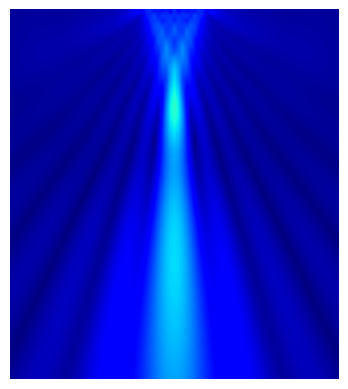

6.0 3.2 17


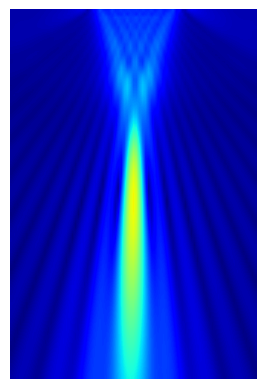

0.0 8.0 44


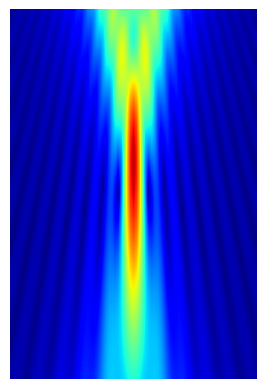

7.0 8.0 51


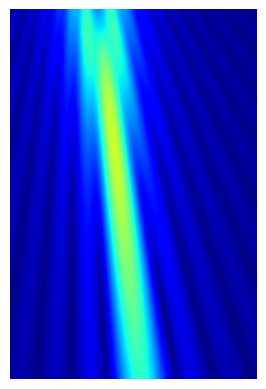

0.0 16.0 99


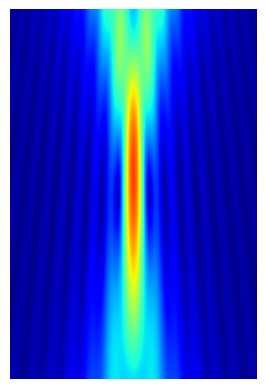

5.0 16.0 104


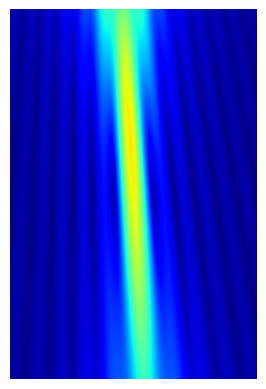

10.0 16.0 109


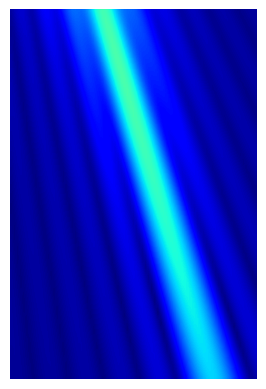

In [22]:
plot_selected = True
# Select some points
x_f_select = [0, 6, 0, 7, 0, 5, 10]
z_f_select = [2, 4, 8, 8, 16, 16, 16]

x_i = [np.argmin(np.abs(x_focus - xf)) for xf in x_f_select]
z_i = [np.argmin(np.abs(z_focus - zf)) for zf in z_f_select]

print('Selected x focus (mm): ', x_focus[x_i])
print('Selected z focus (mm): ', z_focus[z_i])

# Correct linear index for a (x, z) grid
selected_indices = [xi * len(z_focus) + zi for xi, zi in zip(x_i, z_i)]
print('Selected linear indices: ', selected_indices)


if plot_selected:
    for xi, zi in zip(x_i, z_i):
        idx = (zi-1) * len(x_focus) + xi
        focus_mm = np.array([x_focus[xi], y_focus, z_focus[zi]])
        x_shift_simu = 0
        z_shift_simu = 0
        xf = x_focus[xi]
        zf = z_focus[zi]
        
        print(xf, zf, idx)
        if xf >= 7 and zf > 5:
            z_shift_simu += -2
        if xf > 8.5:
            x_shift_simu += -1
        x_min, x_max = -2 + xf + x_shift_simu, 2 + xf + x_shift_simu
        z_min, z_max = -Delta_z + zf + z_shift_simu, Delta_z + zf + z_shift_simu
        if z_min < 0.1:
            z_min = 0.1

        plt.figure()
        plt.imshow(planes[idx].T / np.max(max_pressure), extent=[x_min, x_max, z_max, z_min], aspect='equal', cmap='jet', vmin=0, vmax=1, interpolation='bilinear')
        # plt.plot(xf, zf, 'wx', markersize=10, markeredgewidth=2)
        # plt.plot(max_locations[xi, zi, 0], max_locations[xi, zi, 1], 'wp', markersize=8, markeredgewidth=2)
        # plt.colorbar(label='Normalized Pressure (a.u.)')
        plt.axis('off')
        plt.show() 
        plt.close()


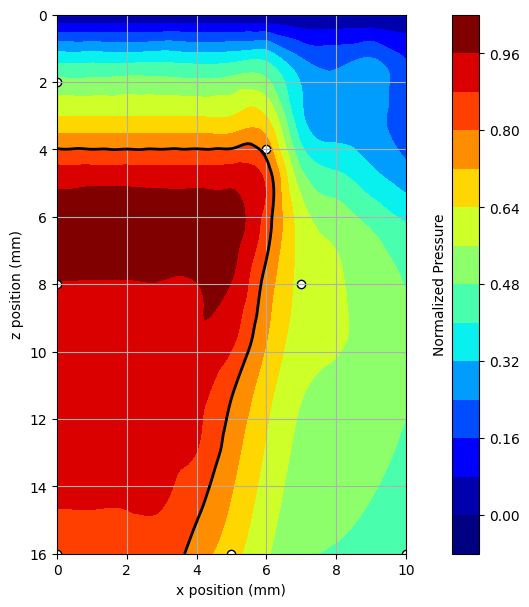

In [23]:
from scipy.interpolate import griddata

# Original grid
X, Z = np.meshgrid(x_focus, z_focus)
focal_points = np.array([X.flatten(), Z.flatten()]).T

# Create a finer grid
x_fine = np.linspace(x_focus.min(), x_focus.max(), 100)
z_fine = np.linspace(z_focus.min(), z_focus.max(), 100)
X_fine, Z_fine = np.meshgrid(x_fine, z_fine)

# Values to interpolate
normalize_pressure = max_pressure.T.flatten()/np.max(max_pressure)
displacement = focal_shift.T.flatten()

# Interpolate
max_pressure_fine = griddata(focal_points, normalize_pressure, (X_fine, Z_fine), method='cubic')
displacement_fine = griddata(focal_points, displacement, (X_fine, Z_fine), method='cubic')

# Compute vector components
Xq = focal_location[:,:,0].flatten()
Zq = focal_location[:,:,1].flatten()
U = max_locations[:,:,0].flatten() - Xq
V = max_locations[:,:,1].flatten() - Zq

# Figures
fig, ax = plt.subplots(1,1, figsize=(6,7))

if isinstance(ax, np.ndarray):
    ax = ax.flatten()
else :
    ax = [ax]

# Plot
im1 = ax[0].contourf(x_fine, z_fine, max_pressure_fine, levels=15, cmap='jet', vmin=0, vmax=1)
ax[0].scatter(x_f_select, z_f_select, c='white', edgecolors='black', label='Focus Locations')
im1.set_clim(0, 1)  # Set limits on the contourf mappable
# ax[0].scatter(max_locations[:, :, 0], max_locations[:, :, 1], c='white', edgecolors='black', label='Max Locations')
# ax[0].scatter(focal_points[:,0], focal_points[:,1], c='gray', edgecolors='black', label='Focus Locations')
# Add 80% contour line
contour_80 = ax[0].contour(x_fine, z_fine, max_pressure_fine, levels=[0.8], colors='k', linewidths=2)
# ax[0].clabel(contour_80, fmt='80%%', colors='k', fontsize=12)


cbar1 = plt.colorbar(im1, label='Normalized Pressure', ax=ax[0], pad = 0.1)
cbar1.ax.yaxis.set_label_position('left')
ax[0].invert_yaxis()
ax[0].set_xlabel('x position (mm)')
ax[0].set_ylabel('z position (mm)')
# ax[0].set_title('a)')
ax[0].grid()

# # im2 = ax[1].imshow(displacement_fine.reshape((len(x_fine), len(z_fine))),
# #             extent=[x_fine.min(), x_fine.max(), z_fine.max(), z_fine.min()],
# #             cmap='hot', aspect= 'auto', interpolation='bilinear')
# im2 = ax[1].contourf(x_fine, z_fine, displacement_fine, cmap='jet', levels=5)
# cbar2 = plt.colorbar(im2,label='Max pressure position shift (mm)', ax=ax[1], pad = 0.1)
# cbar2.ax.yaxis.set_label_position('left')

# # Plot vectors
# ax[1].quiver(Xq ,Zq , U, V,
#             color='black', angles='xy',  width=0.005)
# ax[1].invert_yaxis()
# ax[1].set_xlabel('x position (mm)')
# ax[1].set_ylabel('z position (mm)')
# ax[1].set_title('b) ')
# ax[1].grid()
# ax[1].axis('equal')

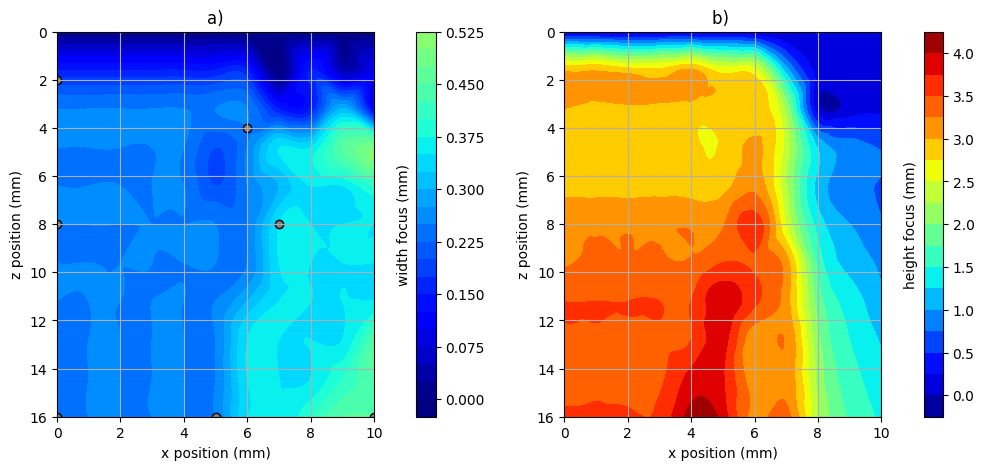

In [24]:
from scipy.interpolate import griddata

# Values to interpolate
width_focal = focal_dimension[:,:,0].T.flatten()
height_focal = focal_dimension[:,:,1].T.flatten()

# Interpolate
width_focal_fine = griddata(focal_points, width_focal, (X_fine, Z_fine), method='cubic')
height_focal_fine = griddata(focal_points, height_focal, (X_fine, Z_fine), method='cubic')

# Compute vector components
Xq = focal_location[:,:,0].flatten()
Zq = focal_location[:,:,1].flatten()
U = max_locations[:,:,0].flatten() - Xq
V = max_locations[:,:,1].flatten() - Zq

# Figures
fig, ax = plt.subplots(1,2,figsize=(12,5))

ax = ax.flatten()

# Plot
im1 = ax[0].contourf(x_fine, z_fine, width_focal_fine, levels=20, cmap='jet', vmin=0, vmax=1)
im1.set_clim(0, 1)  # Set limits on the contourf mappable
# ax[0].scatter(max_locations[:, :, 0], max_locations[:, :, 1], c='white', edgecolors='black', label='Max Locations')
ax[0].scatter(x_f_select, z_f_select, c='gray', edgecolors='black', label='Focus Locations')
cbar1 = plt.colorbar(im1, label='width focus (mm)', ax=ax[0], pad = 0.1)
cbar1.ax.yaxis.set_label_position('left')
ax[0].invert_yaxis()
ax[0].set_xlabel('x position (mm)')
ax[0].set_ylabel('z position (mm)')
ax[0].set_title('a)')
ax[0].grid()

# im2 = ax[1].imshow(displacement_fine.reshape((len(x_fine), len(z_fine))),
#             extent=[x_fine.min(), x_fine.max(), z_fine.max(), z_fine.min()],
#             cmap='hot', aspect= 'auto', interpolation='bilinear')
im2 = ax[1].contourf(x_fine, z_fine, height_focal_fine, cmap='jet', levels=20)
cbar2 = plt.colorbar(im2,label='height focus (mm)', ax=ax[1], pad = 0.1)
cbar2.ax.yaxis.set_label_position('left')

# Plot vectors
ax[1].invert_yaxis()
ax[1].set_xlabel('x position (mm)')
ax[1].set_ylabel('z position (mm)')
ax[1].set_title('b) ')
ax[1].grid()

### 2.4. 